In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('parkinsons.data')
df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [4]:
df.shape

(195, 24)

In [5]:
#find null values
df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [6]:
df.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

In [7]:
for i in df.columns:
    print("***************************************",i,
          "***************************************")
    print()
    print(set(df[i].tolist()))
    print()

*************************************** name ***************************************

{'phon_R01_S17_4', 'phon_R01_S37_2', 'phon_R01_S27_1', 'phon_R01_S27_4', 'phon_R01_S33_4', 'phon_R01_S18_4', 'phon_R01_S26_6', 'phon_R01_S31_6', 'phon_R01_S44_6', 'phon_R01_S21_3', 'phon_R01_S21_2', 'phon_R01_S21_7', 'phon_R01_S24_5', 'phon_R01_S32_6', 'phon_R01_S50_4', 'phon_R01_S13_2', 'phon_R01_S35_1', 'phon_R01_S10_2', 'phon_R01_S49_2', 'phon_R01_S02_3', 'phon_R01_S34_6', 'phon_R01_S17_2', 'phon_R01_S02_1', 'phon_R01_S35_2', 'phon_R01_S33_1', 'phon_R01_S33_2', 'phon_R01_S42_1', 'phon_R01_S39_4', 'phon_R01_S24_3', 'phon_R01_S42_2', 'phon_R01_S39_6', 'phon_R01_S22_6', 'phon_R01_S50_2', 'phon_R01_S04_3', 'phon_R01_S35_7', 'phon_R01_S44_3', 'phon_R01_S08_4', 'phon_R01_S19_5', 'phon_R01_S04_5', 'phon_R01_S10_3', 'phon_R01_S21_6', 'phon_R01_S27_2', 'phon_R01_S25_6', 'phon_R01_S18_6', 'phon_R01_S43_6', 'phon_R01_S26_5', 'phon_R01_S37_6', 'phon_R01_S16_2', 'phon_R01_S06_4', 'phon_R01_S42_6', 'phon_R01_S17

In [8]:
df['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

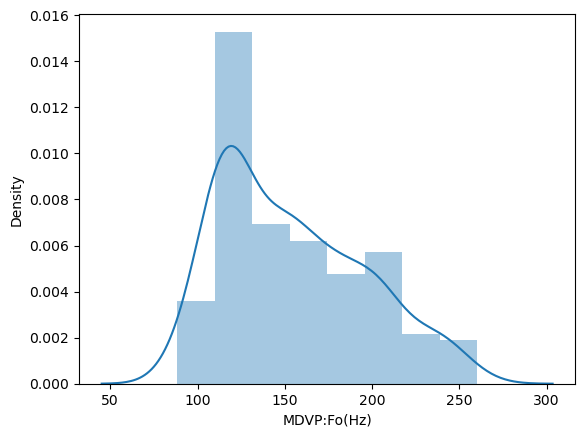

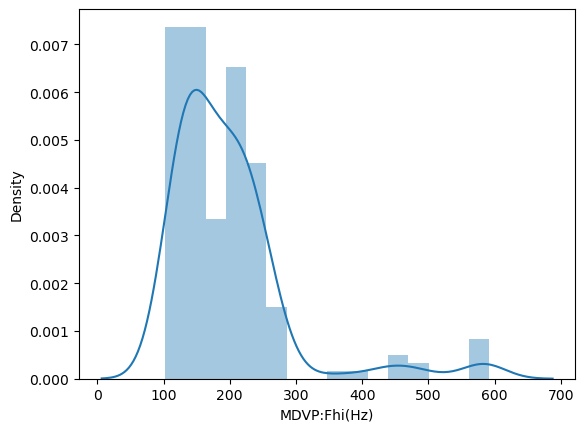

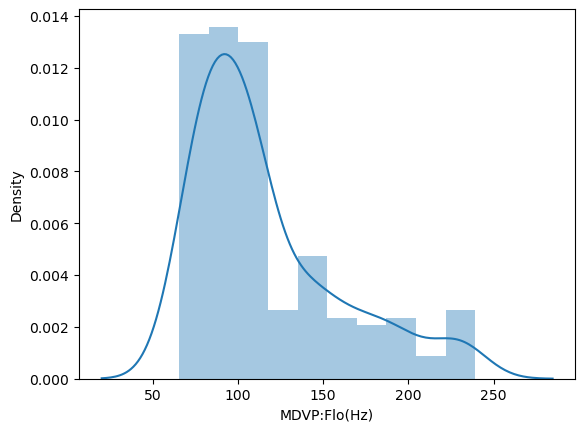

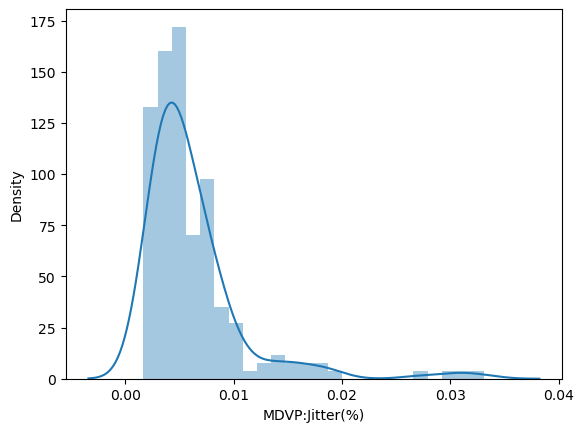

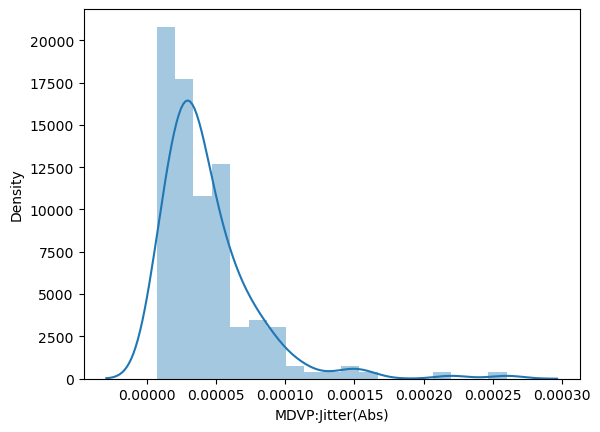

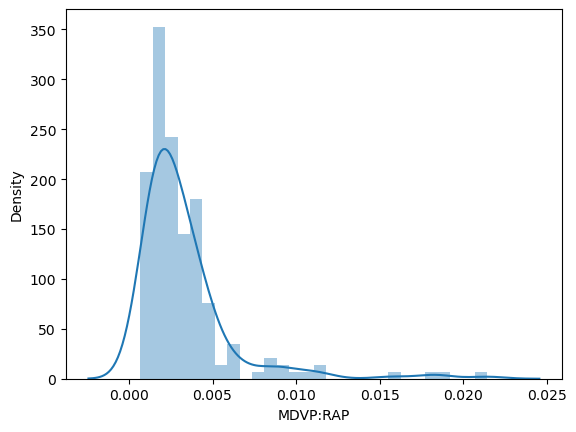

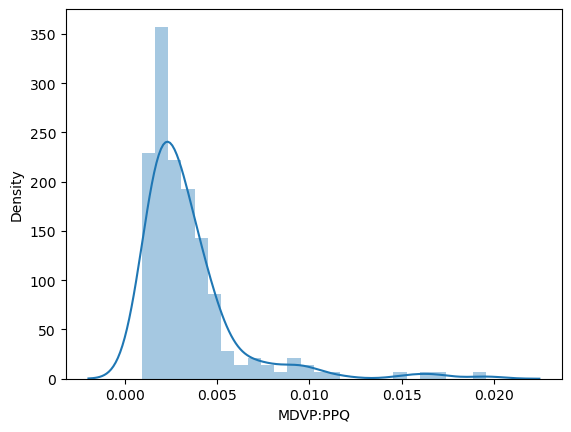

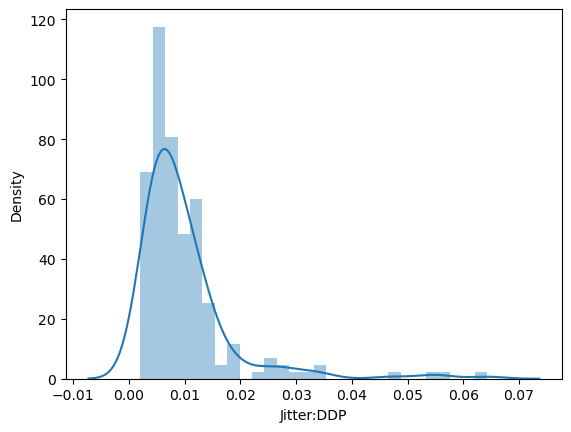

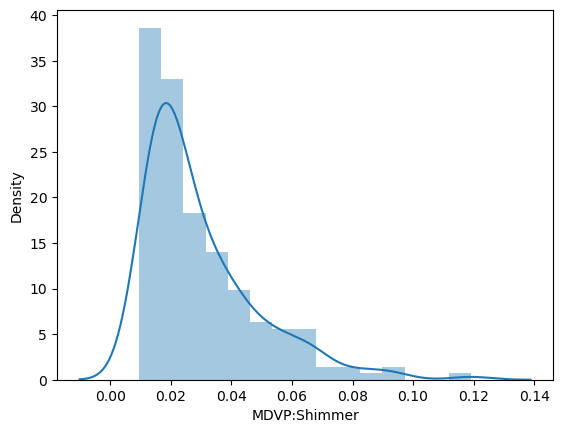

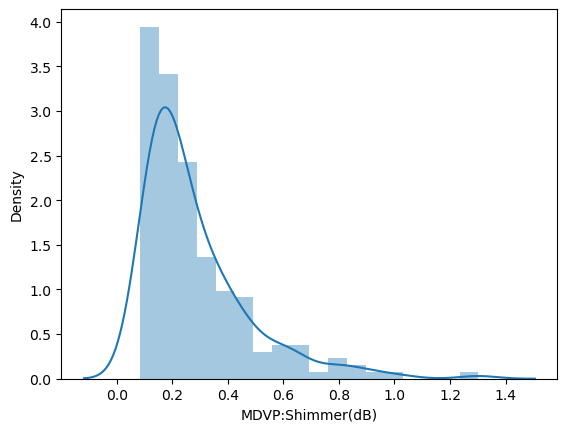

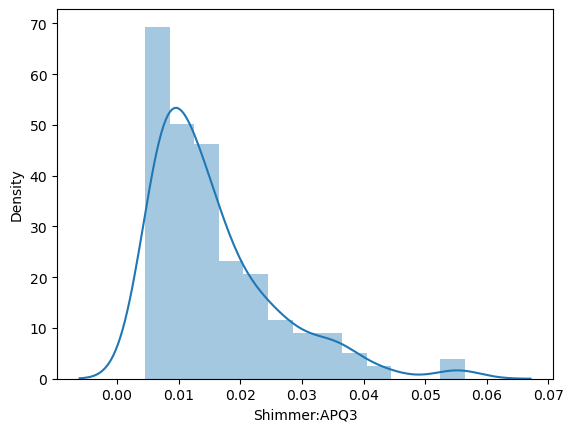

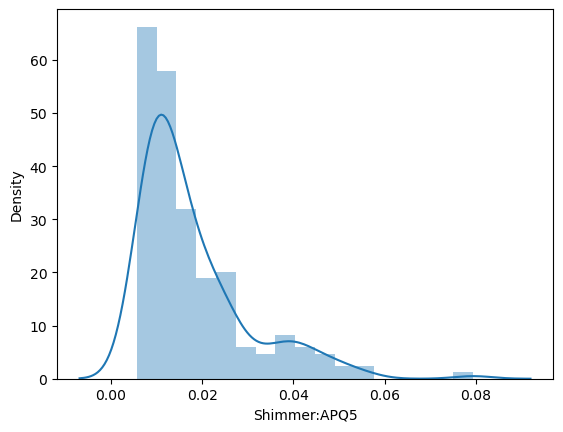

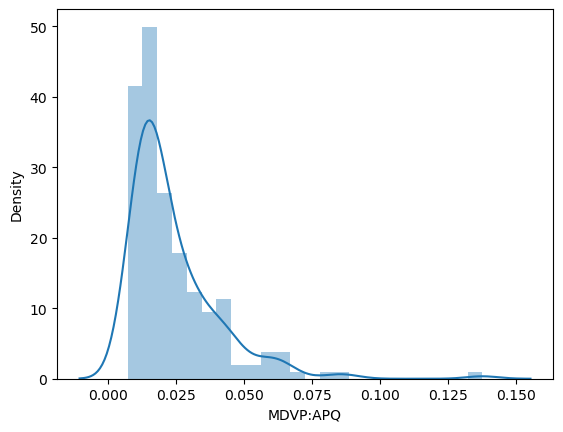

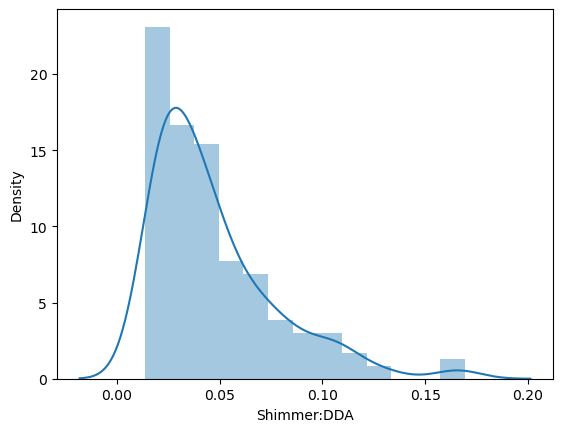

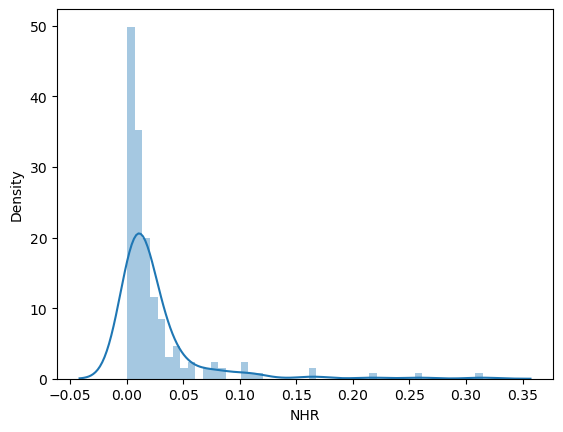

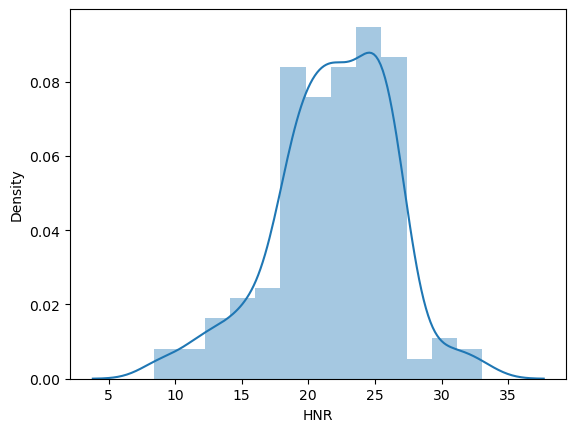

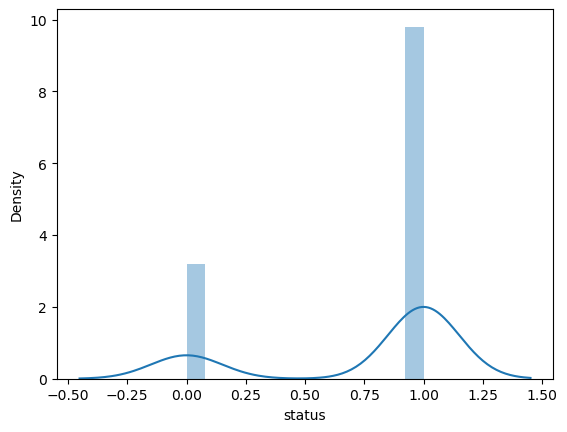

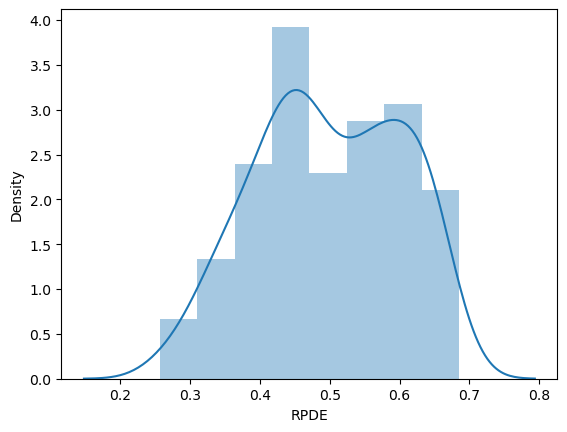

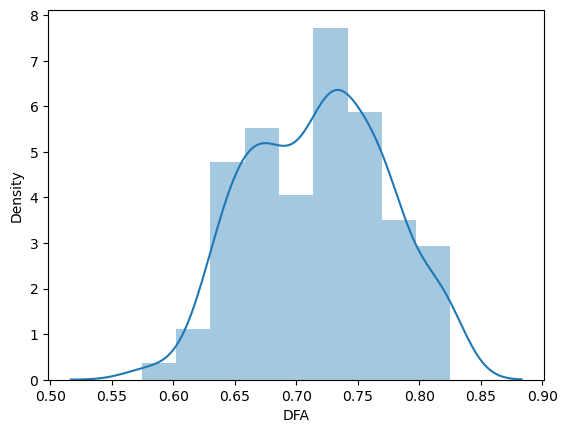

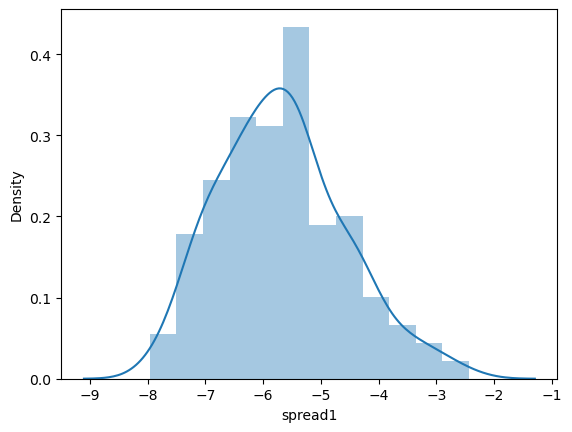

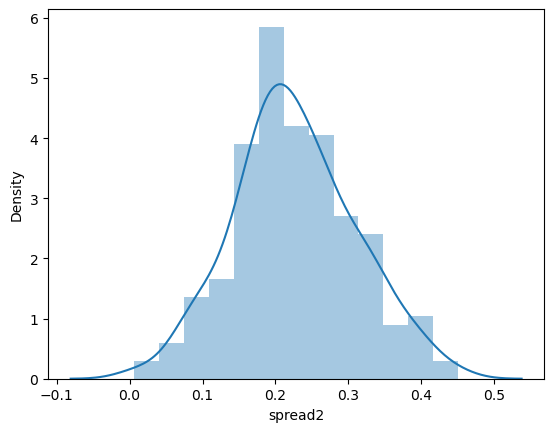

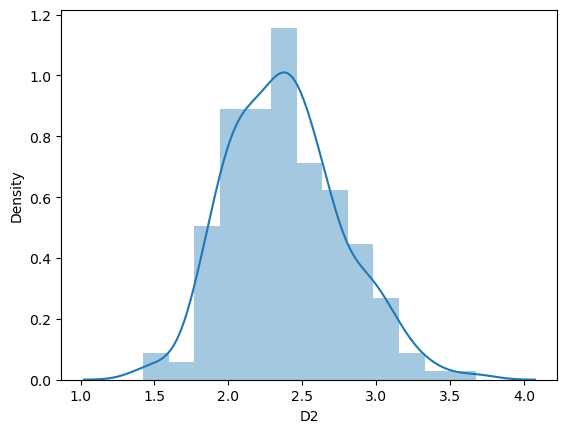

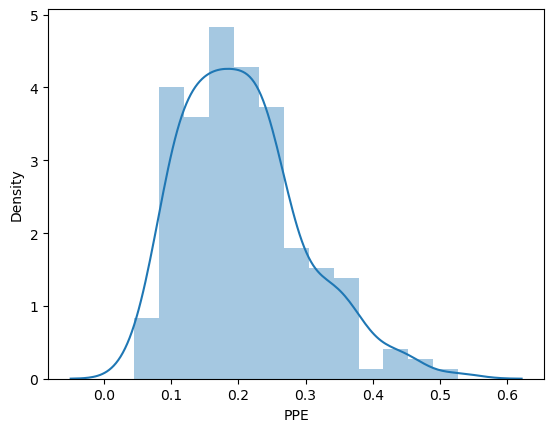

In [9]:
# find the distribustion dataset
def distplot(col):
    sns.distplot(df[col])
    plt.show()  
for i in list(df.columns)[1:]:
    distplot(i)

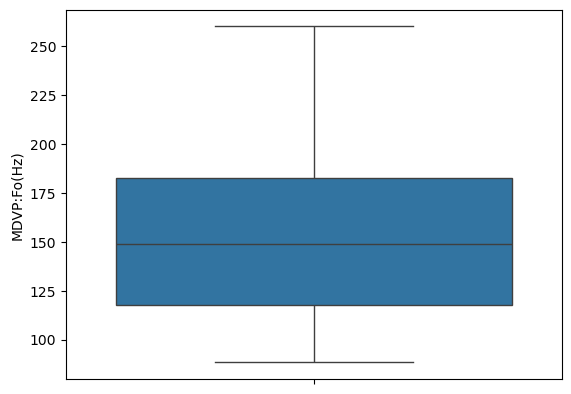

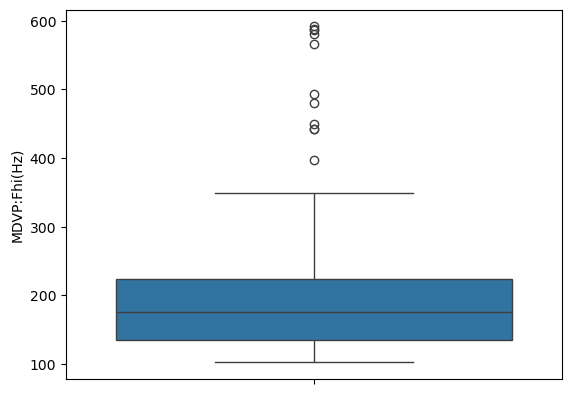

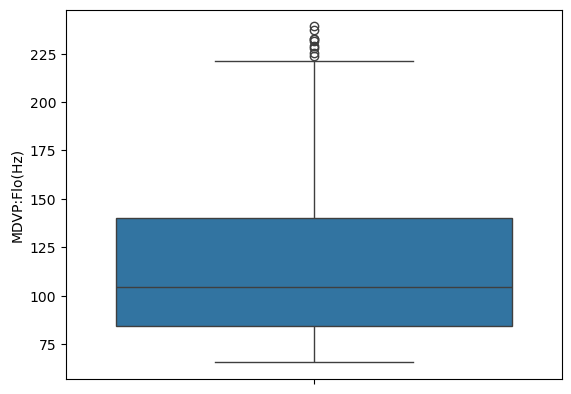

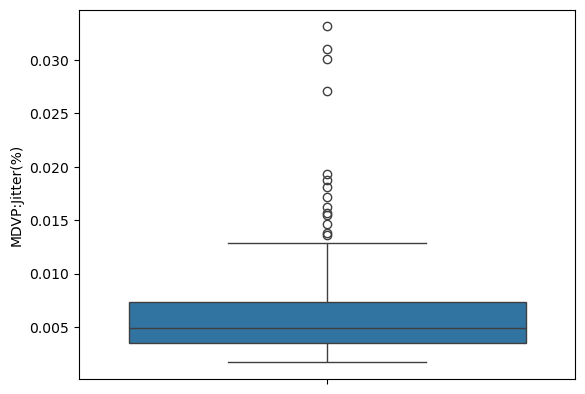

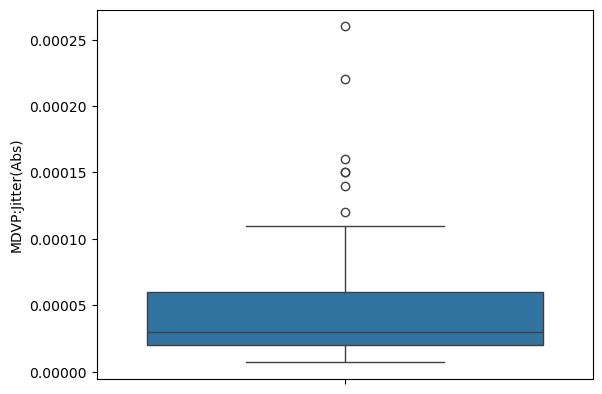

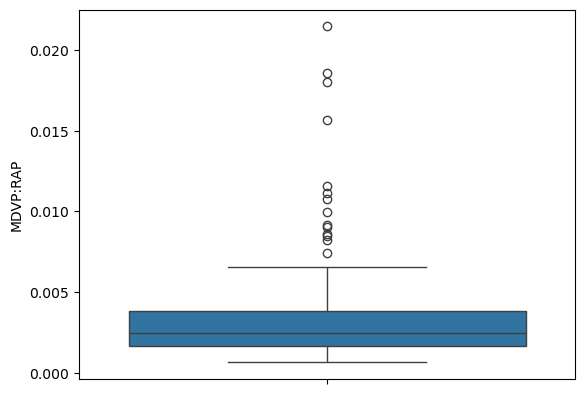

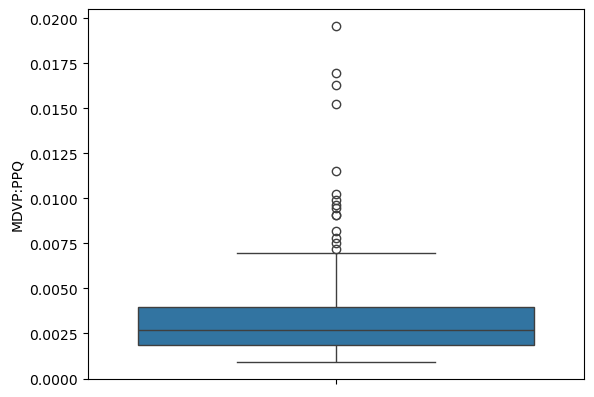

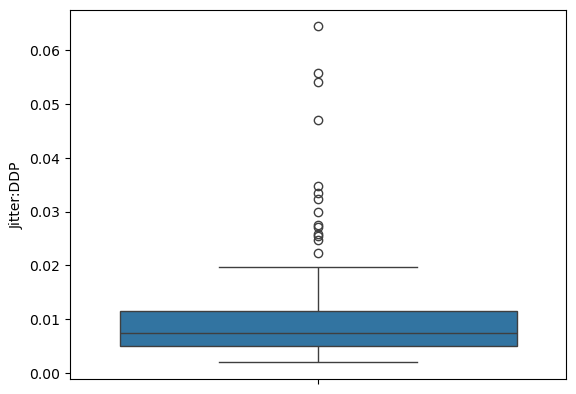

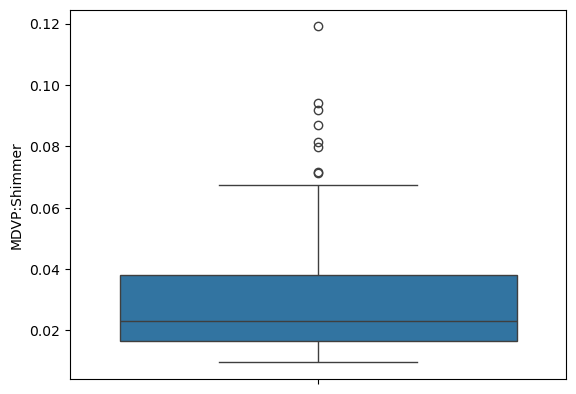

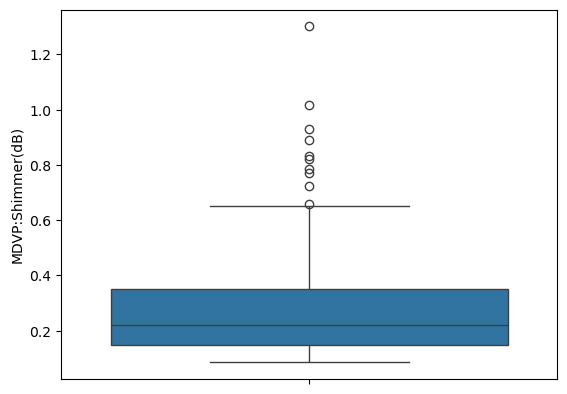

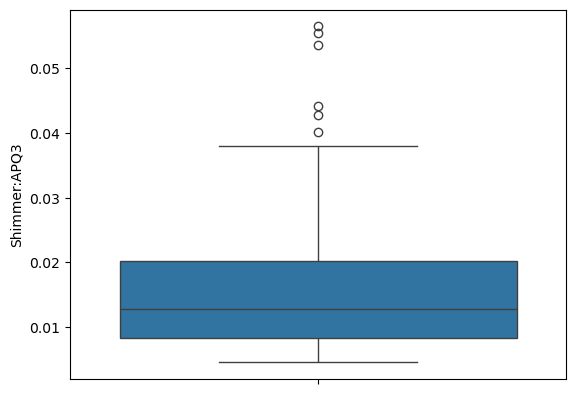

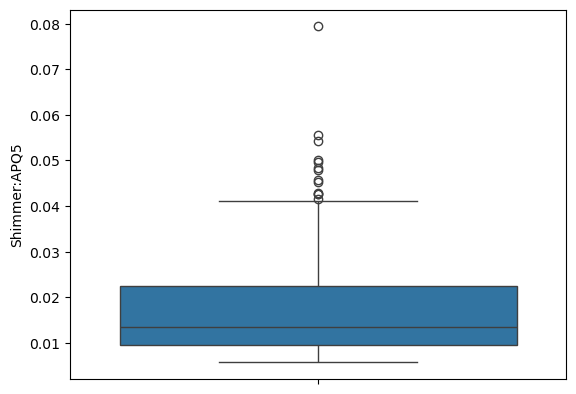

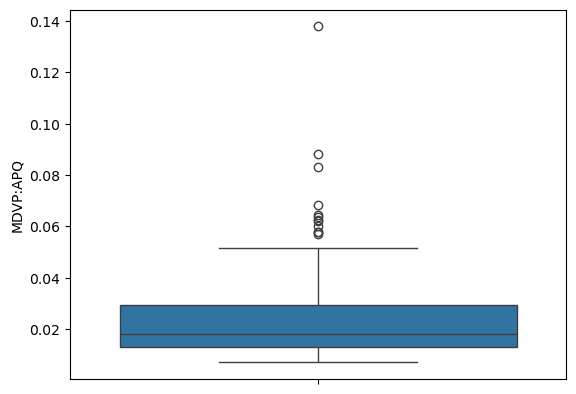

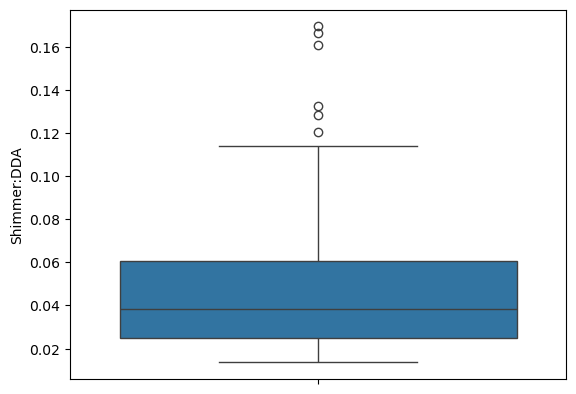

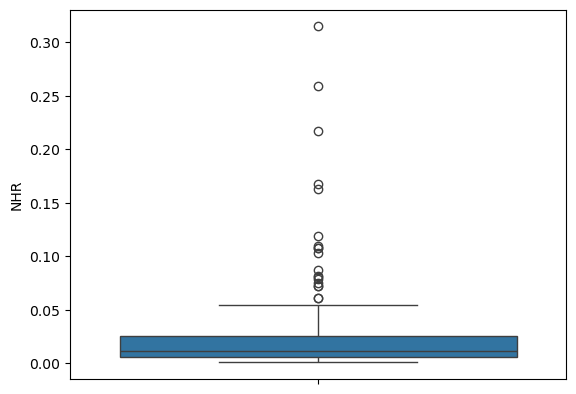

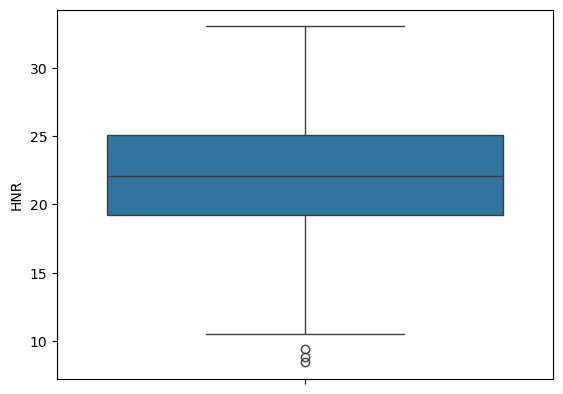

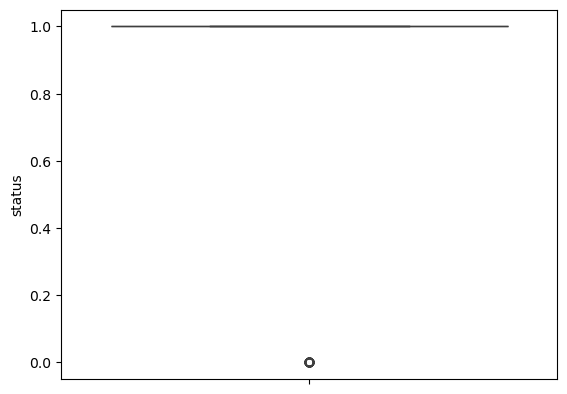

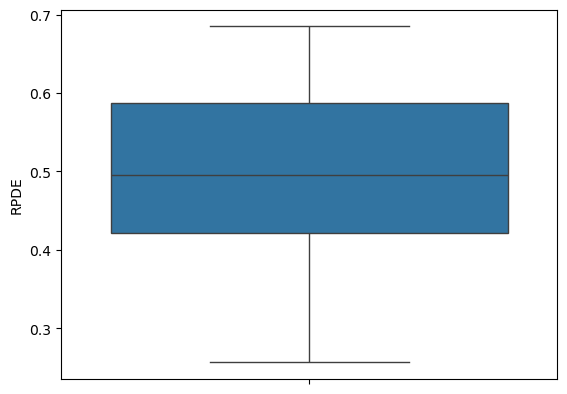

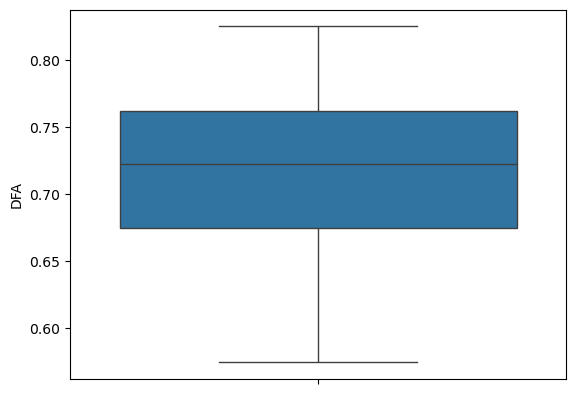

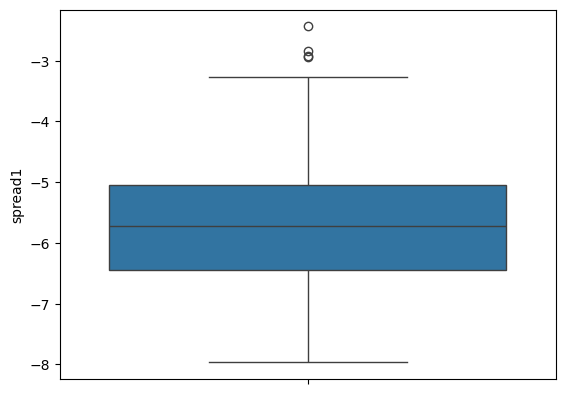

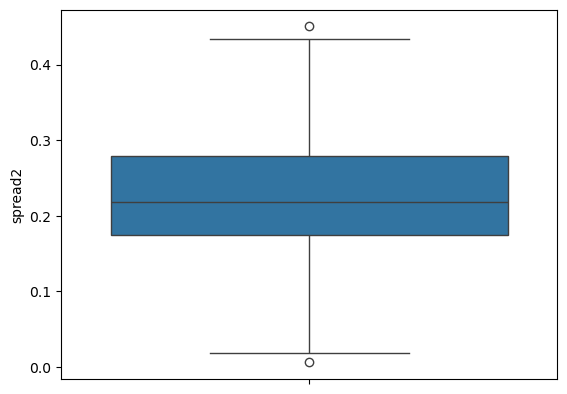

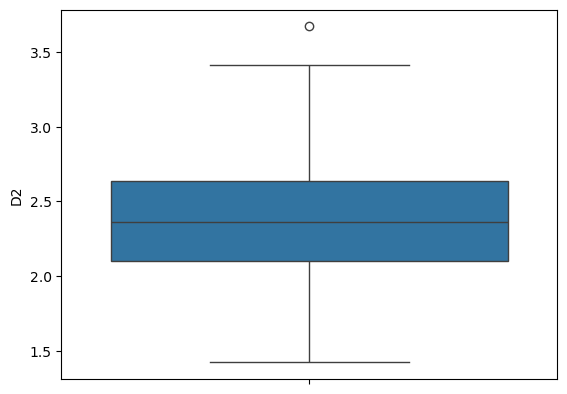

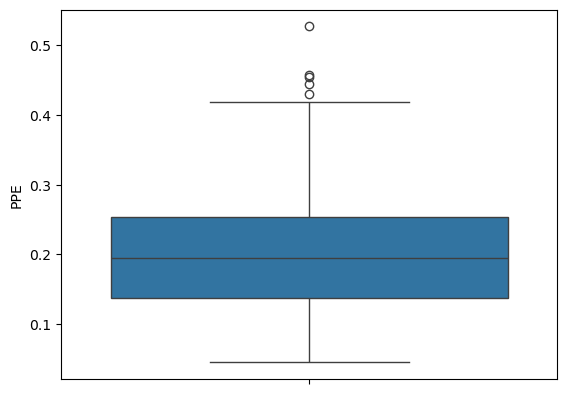

In [10]:
def boxplot(col):
    sns.boxplot(df[col])
    plt.show()  
for i in list(df.columns)[1:]:
    boxplot(i)

In [11]:
df.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

In [12]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [13]:
df = df.drop(['name'], axis=1)

<Axes: >

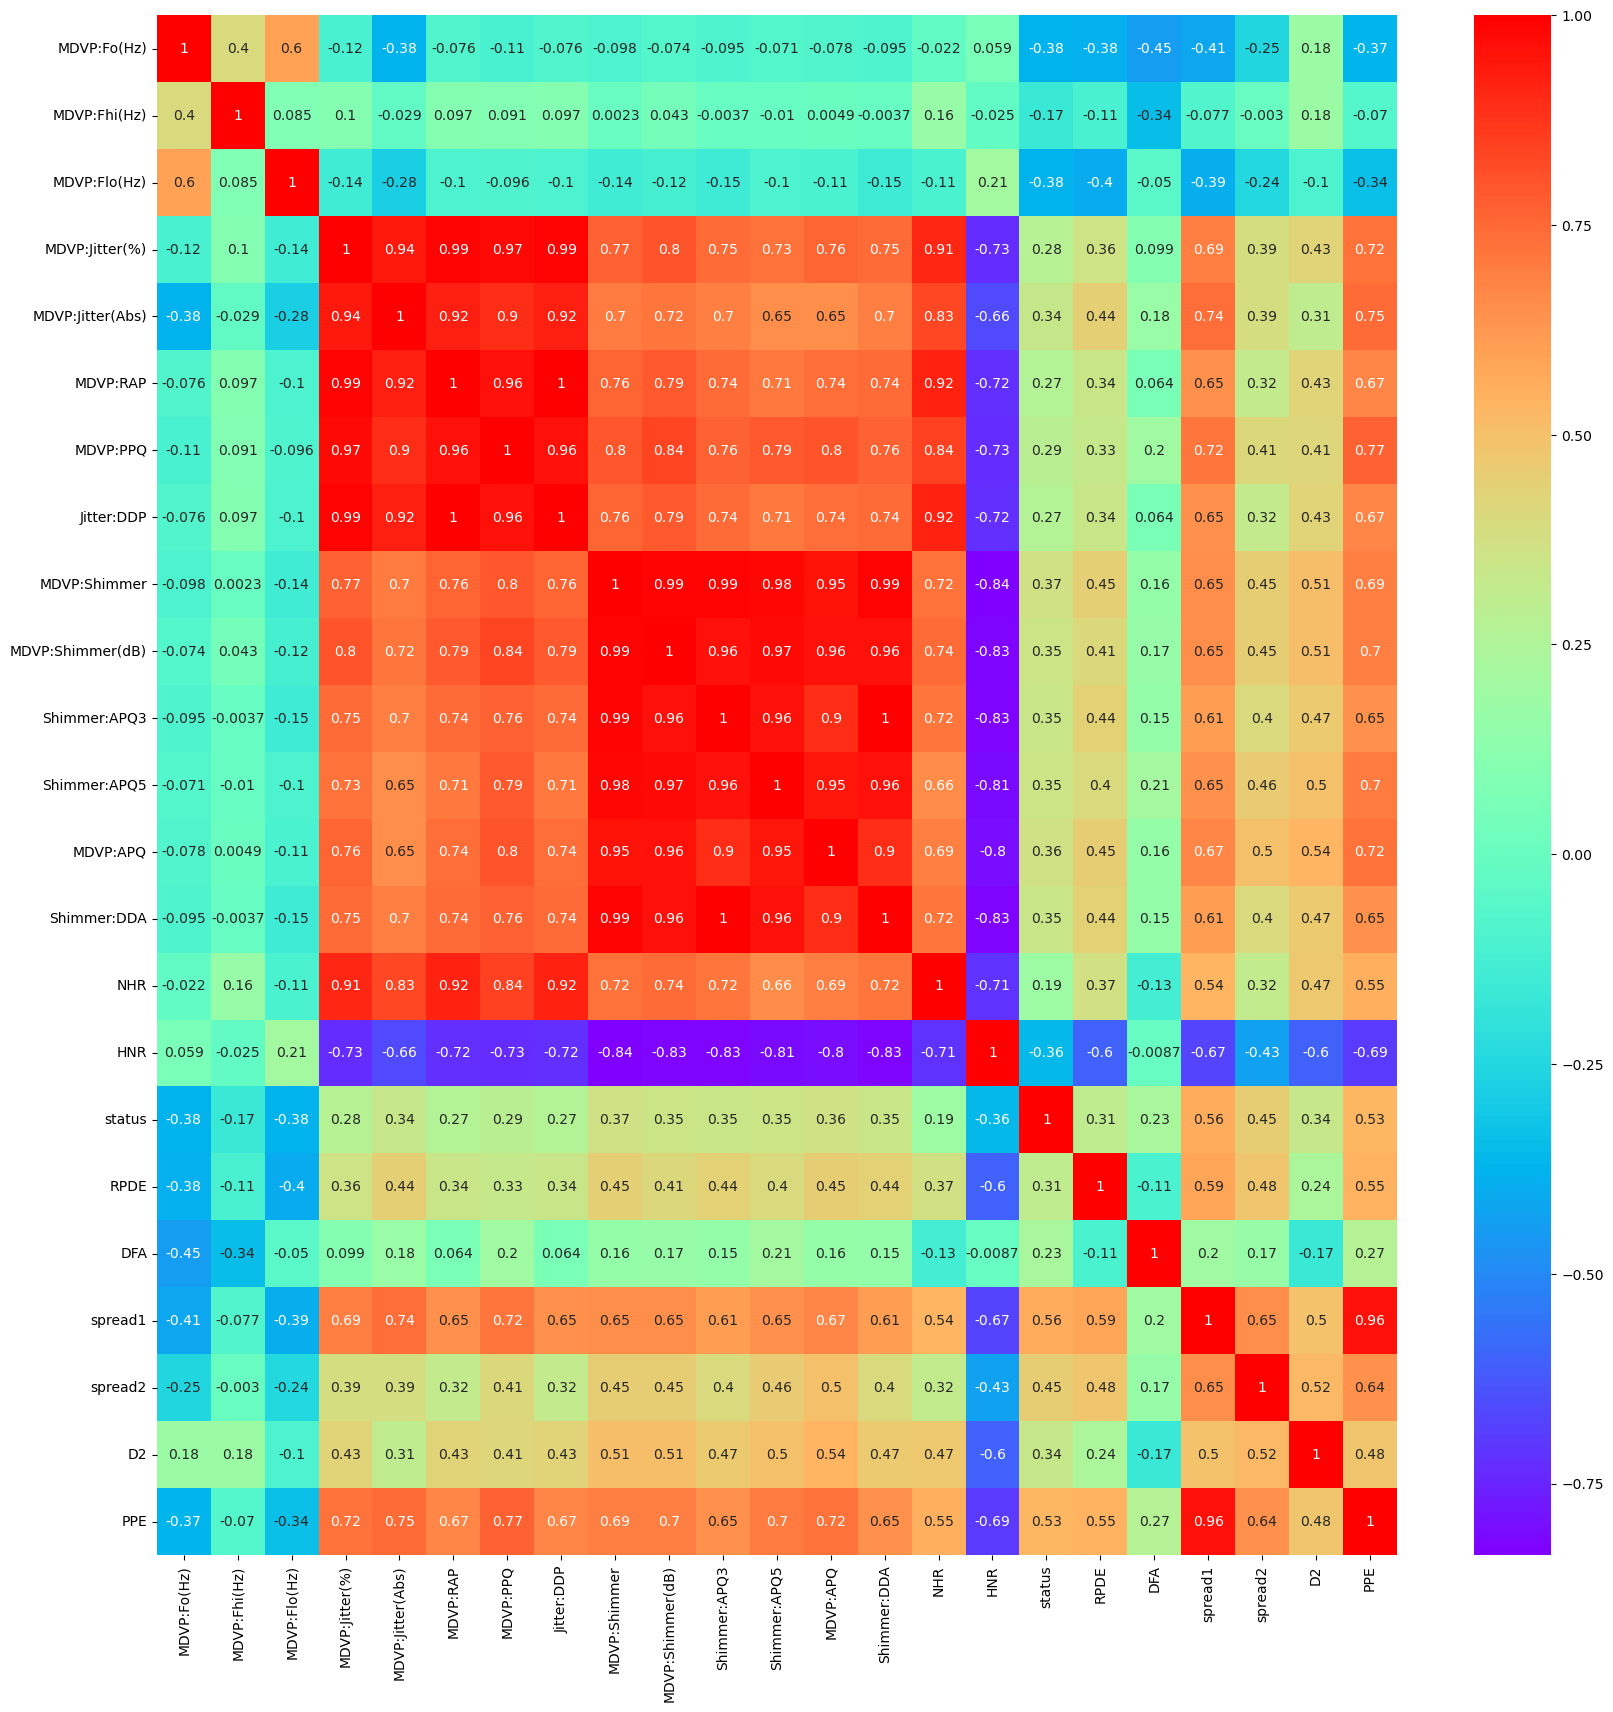

In [14]:
# FIND CORELATION 
plt.figure(figsize=(20,20))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='rainbow')

In [15]:
x = df .drop(['status'], axis=1)
y = df['status']    

In [16]:
x.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [17]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: status, dtype: int64

In [18]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
x_res, y_res = ros.fit_resample(x,y)
print(y.value_counts())
print("##################")
print(y_res.value_counts())

status
1    147
0     48
Name: count, dtype: int64
##################
status
1    147
0    147
Name: count, dtype: int64


In [19]:
# feature scaling
from sklearn.preprocessing import MinMaxScaler


In [20]:
scaler = MinMaxScaler((-1,1))
x = scaler.fit_transform(x_res)
y = y_res

# PREPROCESSING PART COMPLETED


In [21]:
x.shape

(294, 22)

# appling PCA

In [22]:
from sklearn.decomposition import PCA


In [23]:
pca = PCA(.95)
x_pca = pca.fit_transform(x)
print(x.shape)
print(x_pca.shape)

(294, 22)
(294, 8)


In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=1)


# Model building

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

            method_use  accuracy
0  Logistic Regression  0.847458
1        Decision Tree  0.932203
2        Random Forest  0.983051
3       Random Forest2  0.983051
4                  SVM  0.983051
5                  KNN  0.966102
6          Naive Bayes  0.864407
7          BernoulliNB  0.813559
8    Voting Classifier  0.949153
Axes(0.125,0.11;0.775x0.77)


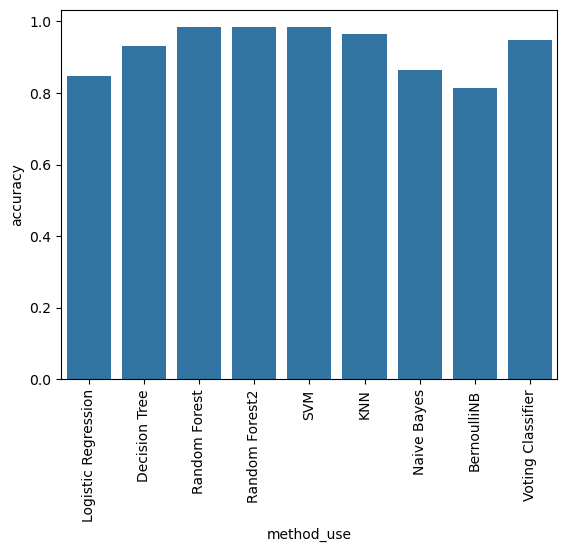

In [ ]:
list_metrics = []
list_accuracy = []
# model 1
# logistic regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(x_train, y_train)

#pridiction
y_pred = classifier.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

#model 2
from sklearn.tree import DecisionTreeClassifier
clssifier2 = DecisionTreeClassifier(random_state=14)
dt = clssifier2.fit(x_train, y_train)
# pridiction
y_pred2 = clssifier2.predict(x_test)
# evaluation
accuracy_DT = accuracy_score(y_test, y_pred2)
# model 3
from sklearn.ensemble import RandomForestClassifier
classifier3 = RandomForestClassifier(random_state=14)
rf = classifier3.fit(x_train, y_train)
# pridiction
y_pred3 = classifier3.predict(x_test)
# evaluation
accuracy_RF = accuracy_score(y_test, y_pred3)

# model 4
classifier4 = RandomForestClassifier(criterion='entropy', random_state=14)
rf2 = classifier4.fit(x_train, y_train)
# pridiction    
y_pred4 = classifier4.predict(x_test)
# evaluation
accuracy_RF2 = accuracy_score(y_test, y_pred4)

# model 5
from sklearn.svm import SVC
model_svm = SVC()
SVM = model_svm.fit(x_train, y_train)
# pridiction
y_pred5 = model_svm.predict(x_test)
# evaluation
accuracy_SVM = accuracy_score(y_test, y_pred5)  

# model 6
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
KNN = model_knn.fit(x_train, y_train)
# pridiction    
y_pred6 = model_knn.predict(x_test)
# evaluation    
accuracy_KNN = accuracy_score(y_test, y_pred6)

# model 7
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()
model_nb = model_nb.fit(x_train, y_train)
# pridiction
y_pred7 = model_nb.predict(x_test)
# evaluation
accuracy_nb = accuracy_score(y_test, y_pred7)

# model 8
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()
bnb  = model.fit(x_train, y_train)
# pridiction
y_pred8 = model.predict(x_test)
# evaluation
accuracy_bnb = accuracy_score(y_test, y_pred8)

# combine all the above model by using voting classifer model
from sklearn.ensemble import VotingClassifier
evc = VotingClassifier(estimators=[('lr', classifier), ('dt', clssifier2), ('rf', classifier3), ('rf2', classifier4), ('svm', model_svm), ('knn', model_knn), ('nb', model_nb), ('bnb', model)], voting='hard', flatten_transform=True)
model_evc = evc.fit(x_train, y_train)
# pridiction    
y_pred9 = model_evc.predict(x_test)
# evaluation
accuracy_evc = accuracy_score(y_test, y_pred9)

list1 = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Random Forest2', 'SVM', 'KNN', 'Naive Bayes', 'BernoulliNB', 'Voting Classifier']
list2 = [accuracy, accuracy_DT, accuracy_RF, accuracy_RF2, accuracy_SVM, accuracy_KNN, accuracy_nb, accuracy_bnb, accuracy_evc]

list3 = [classifier, clssifier2, classifier3, classifier4, model_svm, model_knn, model_nb, model, evc]



df_accuracy = pd.DataFrame({"method_use": list1, "accuracy": list2})
print(df_accuracy)

chart = sns.barplot(x='method_use', y='accuracy', data=df_accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
print(chart)





##Model Accuracy Comparison

In [27]:

from xgboost import XGBClassifier
model_xgb = XGBClassifier()
model_xgb.fit(x_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred_xgb = model_xgb.predict(x_test)
print("accuracy of xgboost model is ", accuracy_score(y_test, y_pred_xgb))

accuracy of xgboost model is  0.9491525423728814


In [29]:
# other evaluation methods
from sklearn.metrics import roc_curve, auc


In [30]:
# random forest entropy
y_pred4_train = classifier4.predict(x_train)
y_pred4_prob = classifier4.predict(x_test)

# KNN
y_pred6_train = model_knn.predict(x_train)
y_pred6 = model_knn.predict(x_test)


In [31]:
print(confusion_matrix(y_train, y_pred4_train))
print("********************************"*5)
print(confusion_matrix(y_test, y_pred4_prob))

[[118   0]
 [  0 117]]
****************************************************************************************************************************************************************
[[29  0]
 [ 1 29]]


In [32]:
print(classification_report(y_train, y_pred4_train))
print("********************************"*5)
print(classification_report(y_test, y_pred4_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00       117

    accuracy                           1.00       235
   macro avg       1.00      1.00      1.00       235
weighted avg       1.00      1.00      1.00       235

****************************************************************************************************************************************************************
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        30

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



In [33]:
print(confusion_matrix(y_train, y_pred6_train))
print("********************************"*5)
print(confusion_matrix(y_test, y_pred6))    

[[118   0]
 [  7 110]]
****************************************************************************************************************************************************************
[[29  0]
 [ 2 28]]


In [34]:
print(classification_report(y_train, y_pred6_train))
print("********************************"*5)
print(classification_report(y_test, y_pred6))    

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       118
           1       1.00      0.94      0.97       117

    accuracy                           0.97       235
   macro avg       0.97      0.97      0.97       235
weighted avg       0.97      0.97      0.97       235

****************************************************************************************************************************************************************
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        29
           1       1.00      0.93      0.97        30

    accuracy                           0.97        59
   macro avg       0.97      0.97      0.97        59
weighted avg       0.97      0.97      0.97        59



# rac and auc

In [35]:
from sklearn.model_selection import cross_val_score

In [36]:
def plot_roc(rf, x_test, y_test):
    probability = model.predict_proba(np.array(x_test))
    prediction = probability
    fpr, tpr, threshold = roc_curve(y_test, prediction[:,1])
    roc_auc = auc(fpr, tpr)
    
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1]) 
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

# ROC Curve Analysis
The ROC Curve achieved an AUC score of 0.91, indicating excellent ability to distinguish Parkinson's patients from healthy individuals.

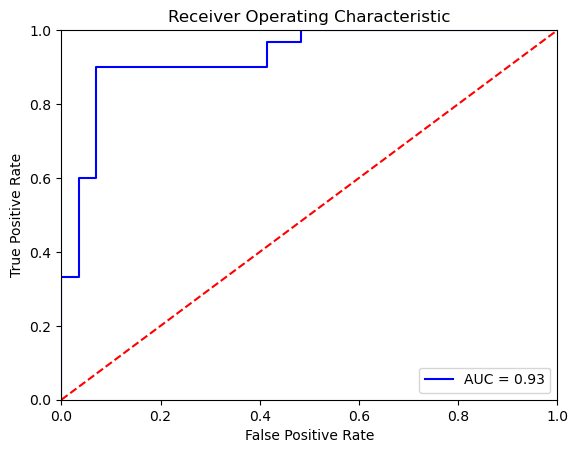

In [37]:
plot_roc(rf, x_test, y_test)